# Lung Cancer Detection

This notebook trains and evaluates multiple machine learning models to classify lung CT scan images into five categories: adenocarcinoma, large cell carcinoma, squamous cell carcinoma, malignant cases, and normal. We compare a classical baseline model (PCA + Logistic Regression) against two variants of a Swin Transformer to quantify the benefit of deep learning for this task.

## Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import classification_report
import kagglehub # For dataset

from torchvision import datasets, transforms
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from torch.utils.data import WeightedRandomSampler

# Pre-trained model
from transformers import SwinModel

from tqdm import tqdm
import os
from PIL import Image

## Data Prep

We use the [CT Scan Images for Lung Cancer](https://www.kaggle.com/datasets/dishantrathi20/ct-scan-images-for-lung-cancer) dataset from Kaggle, which contains labeled CT scan images split into train, validation, and test directories.

Note that the dataset uses inconsistent directory naming across splits (like `Bengin cases` vs `BenginCases`). We standardize all directory names to a better set of class labels. Also, all benign and normal cases are merged into a single `normal` class. This is justified because:
1. Benign cases are severely underrepresented in the dataset
2. Both represent non-malignant outcomes clinically
3. The merge helps us in training without losing useful signal

In [ ]:
# Config for reproducibility
SEED = 42
BATCH_SIZE = 16
IMG_SIZE = 224

DATASET_NAME = "dishantrathi20/ct-scan-images-for-lung-cancer"

In [ ]:
# Dataset download
dataset_root = kagglehub.dataset_download(DATASET_NAME)

print("Raw dataset path:", dataset_root)

Using Colab cache for faster access to the 'ct-scan-images-for-lung-cancer' dataset.
Raw dataset path: /kaggle/input/ct-scan-images-for-lung-cancer


In [ ]:
def find_dataset_root(path):
    """
    Automatically finds the folder containing train/val/test.
    Works even if Kaggle adds extra nesting.
    """
    for root, dirs, files in os.walk(path):
        if "train" in dirs and "test" in dirs:
            return root
    return path

dataset_root = find_dataset_root(dataset_root)

print("Resolved dataset root:", dataset_root)
print(os.listdir(dataset_root))

Resolved dataset root: /kaggle/input/ct-scan-images-for-lung-cancer/LungcancerDataSet/Data
['valid', 'test', 'train']


### Paths

We define a canonical mapping that handles spelling variations across train/val/test splits. All class labels are standardized before any model sees the data.

In [ ]:
TRAIN_DIR = os.path.join(dataset_root, "train")
VAL_DIR = os.path.join(dataset_root, "valid")
TEST_DIR = os.path.join(dataset_root, "test")
TEST_CASES_DIR = os.path.join(dataset_root, "Test cases")

In [ ]:
# Class mapping

def get_all_unique_subdirs(base_dirs):
    all_subdirs = set()
    for base_dir in base_dirs:
        if os.path.exists(base_dir):
            for sub_dir in os.listdir(base_dir):
                if os.path.isdir(os.path.join(base_dir, sub_dir)):
                    all_subdirs.add(sub_dir)
    return sorted(list(all_subdirs))

def get_canonical_class_mapping(all_subdirs):
    canonical_map = {}
    for c in all_subdirs:
        lower_c = c.lower()
        if 'bengin' in lower_c or 'benign' in lower_c or lower_c == 'normal':
            canonical_map[c] = "normal"
        elif 'adenocarcinoma' in lower_c:
            canonical_map[c] = "adenocarcinoma"
        elif 'squamous.cell.carcinoma' in lower_c:
            canonical_map[c] = "squamous.cell.carcinoma"
        elif 'large.cell.carcinoma' in lower_c:
            canonical_map[c] = "large.cell.carcinoma"
        elif 'malignant' in lower_c:
            canonical_map[c] = "malignant_cases"
        else:
            # If a directory doesn't fit a known pattern, use its original name
            # This implies it's a unique and valid class on its own
            canonical_map[c] = c
    return canonical_map

# Collect all unique subdirectories from train, val, test
all_subdirs_across_datasets = get_all_unique_subdirs([TRAIN_DIR, VAL_DIR, TEST_DIR])

# Create a mapping from original directory names to canonical class names
original_to_canonical_map = get_canonical_class_mapping(all_subdirs_across_datasets)

# Get the unique set of canonical class names
canonical_classes = sorted(list(set(original_to_canonical_map.values())))

# Create global class_to_idx and idx_to_class maps
global_class_to_idx = {cls_name: i for i, cls_name in enumerate(canonical_classes)}
global_idx_to_class = {i: cls_name for cls_name, i in global_class_to_idx.items()}

print("Canonical Classes:", canonical_classes)
print("Global Class to Index Mapping:", global_class_to_idx)

Canonical Classes: ['adenocarcinoma', 'large.cell.carcinoma', 'malignant_cases', 'normal', 'squamous.cell.carcinoma']
Global Class to Index Mapping: {'adenocarcinoma': 0, 'large.cell.carcinoma': 1, 'malignant_cases': 2, 'normal': 3, 'squamous.cell.carcinoma': 4}


### Verify Structure

In [ ]:
def check_dir(path, name):
    assert os.path.exists(path), f"{name} not found at {path}"
    print(f"{name} OK:", os.listdir(path))

check_dir(TRAIN_DIR, "Train")
check_dir(VAL_DIR, "Val")
check_dir(TEST_DIR, "Test")

Train OK: ['squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa', 'Bengin cases', 'Malignant cases', 'normal', 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa', 'adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib']
Val OK: ['squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa', 'Bengin cases', 'Malignant cases', 'normal', 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa', 'adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib']
Test OK: ['MalignantCases', 'BenginCases', 'squamous.cell.carcinoma', 'normal', 'adenocarcinoma', 'large.cell.carcinoma']


### Dataset Class

A custom `LungDataset` class handles the inconsistent folder naming by applying the canonical mapping at load time. Each sample is a `(image_tensor, label_index)` pair.

In [ ]:
class LungDataset(Dataset):
    def __init__(self, root_dir, transform=None, class_to_idx_map=None, idx_to_class_map=None, canonical_classes=None):
        self.root_dir = root_dir
        self.transform = transform

        if class_to_idx_map is None or canonical_classes is None:
            raise ValueError("Global class mapping must be provided to LungDataset.")

        self.class_to_idx = class_to_idx_map
        self.classes = canonical_classes # Use the globally defined classes
        self.idx_to_class = idx_to_class_map

        # Redefine internal label_map based on global canonical names
        self.internal_label_map = {}
        original_classes_in_this_dir = sorted(os.listdir(root_dir))
        for c in original_classes_in_this_dir:
            lower_c = c.lower()
            if 'bengin' in lower_c or 'benign' in lower_c or lower_c == 'normal':
                self.internal_label_map[c] = "normal"
            elif 'adenocarcinoma' in lower_c:
                self.internal_label_map[c] = "adenocarcinoma"
            elif 'squamous.cell.carcinoma' in lower_c:
                self.internal_label_map[c] = "squamous.cell.carcinoma"
            elif 'large.cell.carcinoma' in lower_c:
                self.internal_label_map[c] = "large.cell.carcinoma"
            elif 'malignant' in lower_c:
                self.internal_label_map[c] = "malignant_cases" # Corrected to match global canonical name 'malignant_cases'
            else:
                self.internal_label_map[c] = c # Fallback, should ideally be covered by canonical_classes

        self.samples = []
        for c in original_classes_in_this_dir:
            class_path = os.path.join(root_dir, c)
            if not os.path.isdir(class_path):
                continue

            mapped_class_name = self.internal_label_map[c]

            # Ensure the mapped_class_name is in the global canonical list
            if mapped_class_name not in self.class_to_idx:
                print(f"Warning: Mapped class '{mapped_class_name}' from original directory '{c}' not found in global canonical classes. Skipping samples from this class.")
                continue # Skip samples from unmapped classes to prevent errors

            mapped_label = self.class_to_idx[mapped_class_name]

            for img in os.listdir(class_path):
                self.samples.append((
                    os.path.join(class_path, img),
                    mapped_label
                ))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB") # Ensure 3 channels for Swin Transformer

        if self.transform:
            img = self.transform(img)

        return img, label

### Image Transformations

Training images are augmented with random flips, rotations, affine shifts, and color jitter to improve generalization. All images are converted to grayscale (then replicated to 3 channels to match the Swin input format) since CT scans are inherently single-channel. Normalization uses ImageNet statistics, which is standard practice when using pretrained backbones.

In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.Grayscale(num_output_channels=3),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05), scale=(0.95, 1.05)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

### Data Loaders

We examine the training class distribution to understand dataset imbalance, then compute inverse-frequency class weights. These weights are passed to the loss function so the model is penalized more heavily for misclassifying underrepresented classes.

In [ ]:
train_ds = LungDataset(TRAIN_DIR, train_transform, class_to_idx_map=global_class_to_idx, idx_to_class_map=global_idx_to_class, canonical_classes=canonical_classes)
val_ds = LungDataset(VAL_DIR, test_transform, class_to_idx_map=global_class_to_idx, idx_to_class_map=global_idx_to_class, canonical_classes=canonical_classes)
test_ds = LungDataset(TEST_DIR, test_transform, class_to_idx_map=global_class_to_idx, idx_to_class_map=global_idx_to_class, canonical_classes=canonical_classes)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE)

print("Classes in train_ds:", train_ds.classes)

Classes in train_ds: ['adenocarcinoma', 'large.cell.carcinoma', 'malignant_cases', 'normal', 'squamous.cell.carcinoma']


### Class Counts

In [ ]:
class_counts = torch.zeros(len(train_ds.classes))

# Iterate through the actual dataset samples to count classes
for _, label in tqdm(train_ds, desc="Counting train dataset classes"):
    class_counts[label] += 1

print("\nClass distribution in Training Dataset:")
for i, class_name in enumerate(train_ds.classes):
    print(f"{class_name}: {int(class_counts[i])}")

Counting train dataset classes: 100%|██████████| 1460/1460 [00:32<00:00, 45.55it/s]


Class distribution in Training Dataset:
adenocarcinoma: 195
large.cell.carcinoma: 115
malignant_cases: 460
normal: 535
squamous.cell.carcinoma: 155


### Computing Weights

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum()  # normalize

class_weights = class_weights.to(device)

print("Class weights:", class_weights)

Class weights: tensor([0.2109, 0.3576, 0.0894, 0.0769, 0.2653], device='cuda:0')


## Model 1: Swin Transformer

Our primary model uses the **Swin Transformer** (Shifted Window Transformer), a vision transformer architecture that processes images in non-overlapping patches and uses shifted window attention to capture both local and global features efficiently.

We use `microsoft/swin-tiny-patch4-window7-224` pretrained on ImageNet as our backbone, and replace its classification head with a linear layer sized to our 5-class problem.

In this first variant, all parameters are unfrozen from the start, the full model is fine-tuned end-to-end. We use:
- **AdamW** optimizer (weight decay for regularization)
- **CrossEntropyLoss** with class weights
- **ReduceLROnPlateau** scheduler (halves LR if val loss stagnates)
- **Gradient clipping** (max norm = 1.0) to prevent exploding gradients
- **Early stopping** (patience = 3 epochs)

In [ ]:
class SwinClassifier(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.backbone = SwinModel.from_pretrained(
            "microsoft/swin-tiny-patch4-window7-224"
        )

        hidden = self.backbone.config.hidden_size
        self.head = nn.Linear(hidden, num_classes)

    def forward(self, x):
        out = self.backbone(pixel_values=x)
        x = out.last_hidden_state[:, 0]
        return self.head(x)

### Training Setup

In [ ]:
model = SwinClassifier(num_classes=len(train_ds.classes)).to(device)

LR = 3e-5
EPOCHS = 15

# Using class weights
criterion = nn.CrossEntropyLoss(weight = class_weights)
optimizer = optim.AdamW(model.parameters(), lr=LR)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/113M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/231 [00:00<?, ?it/s]

SwinModel LOAD REPORT from: microsoft/swin-tiny-patch4-window7-224
Key               | Status     |  | 
------------------+------------+--+-
classifier.weight | UNEXPECTED |  | 
classifier.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


### Training Loop

In [ ]:
best_val_acc = 0
patience = 3
no_improve_epochs = 0

train_losses = []
val_losses = []
train_accs = []
val_accs = []

# Scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=2
)

for epoch in range(EPOCHS):

    # Train
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        train_loss += loss.item()

        preds = torch.argmax(outputs, dim=1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

    train_loss /= len(train_loader)
    train_acc = train_correct / train_total


    # Validation
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= len(val_loader)
    val_acc = val_correct / val_total

    # Step scheduler AFTER validation
    scheduler.step(val_loss)


    # Saving best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "model1_best.pth")
        no_improve_epochs = 0
        print(f"New best model saved! Val Acc: {val_acc:.4f}")
    else:
        no_improve_epochs += 1


    # Early stopping
    if no_improve_epochs >= patience:
        print(f"\nEarly stopping triggered at epoch {epoch+1}!")
        break


    # Logging losses and accuracies
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    # Print results + LR
    current_lr = optimizer.param_groups[0]['lr']

    print(f"""
Epoch {epoch+1}/{EPOCHS}
LR: {current_lr:.6f}
Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}
Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}
""")

New best model saved! Val Acc: 0.6127

Epoch 1/15
LR: 0.000030
Train Loss: 1.1638 | Train Acc: 0.4966
Val Loss: 0.9186 | Val Acc: 0.6127

New best model saved! Val Acc: 0.7817

Epoch 2/15
LR: 0.000030
Train Loss: 0.8467 | Train Acc: 0.7288
Val Loss: 0.5753 | Val Acc: 0.7817

New best model saved! Val Acc: 0.8310

Epoch 3/15
LR: 0.000030
Train Loss: 0.7025 | Train Acc: 0.8034
Val Loss: 0.4973 | Val Acc: 0.8310

New best model saved! Val Acc: 0.8592

Epoch 4/15
LR: 0.000030
Train Loss: 0.4796 | Train Acc: 0.8712
Val Loss: 0.4438 | Val Acc: 0.8592

New best model saved! Val Acc: 0.8662

Epoch 5/15
LR: 0.000030
Train Loss: 0.4051 | Train Acc: 0.8973
Val Loss: 0.3914 | Val Acc: 0.8662

New best model saved! Val Acc: 0.9085

Epoch 6/15
LR: 0.000030
Train Loss: 0.3664 | Train Acc: 0.9021
Val Loss: 0.3461 | Val Acc: 0.9085

New best model saved! Val Acc: 0.9225

Epoch 7/15
LR: 0.000030
Train Loss: 0.2504 | Train Acc: 0.9397
Val Loss: 0.2949 | Val Acc: 0.9225

New best model saved! Val Acc: 0.9

### Loss and Accuracy Curves

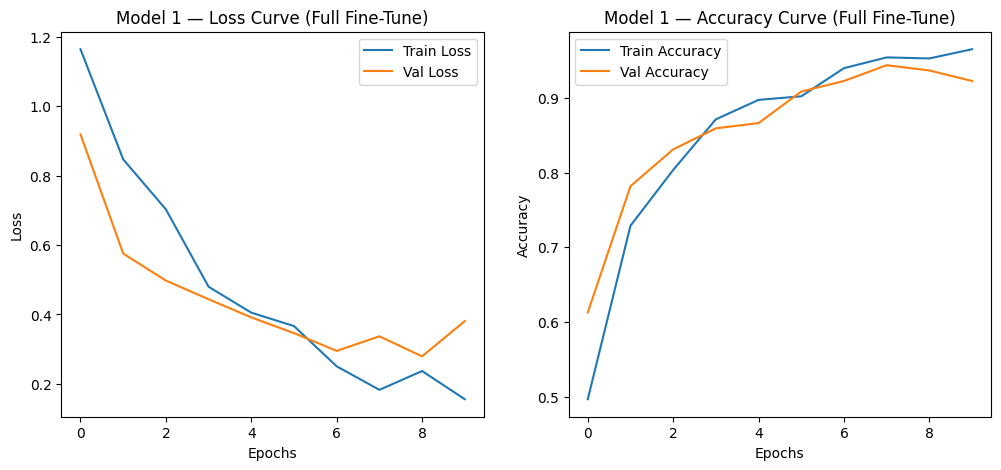

In [ ]:
epochs_range = range(len(train_losses))

plt.figure(figsize=(12, 5))

# Loss Curves
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_losses, label="Train Loss")
plt.plot(epochs_range, val_losses, label="Val Loss")
plt.title("Model 1 — Loss Curve (Full Fine-Tune)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

# Accuracy Plot
plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_accs, label="Train Accuracy")
plt.plot(epochs_range, val_accs, label="Val Accuracy")
plt.title("Model 1 — Accuracy Curve (Full Fine-Tune)")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

### Classification Report

In [ ]:
model.load_state_dict(torch.load("model1_best.pth", map_location=device))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())

print(classification_report(all_labels, all_preds, target_names=test_ds.classes))

                         precision    recall  f1-score   support

         adenocarcinoma       0.73      0.83      0.78       120
   large.cell.carcinoma       0.83      0.96      0.89        51
        malignant_cases       0.94      0.82      0.88        80
                 normal       0.90      0.96      0.93       134
squamous.cell.carcinoma       0.82      0.61      0.70        90

               accuracy                           0.84       475
              macro avg       0.85      0.84      0.84       475
           weighted avg       0.84      0.84      0.83       475



## Model 2: Swin Transformer — Two-Phase Transfer Learning

In this variant we apply a structured transfer learning strategy to avoid catastrophic forgetting, the risk of overwriting useful pretrained features when fine-tuning on a small dataset.

**Phase 1:** Freeze the entire backbone. Train only the classification head for 5 epochs at a higher learning rate (1e-4). This warms up the head without disturbing the backbone.

**Phase 2:** Unfreeze only the last two Swin stages (`layers.2` and `layers.3`). Apply differential learning rates, higher for the head (1e-4), lower for the backbone (2e-5). This allows the deeper layers to adapt to CT scan features while preserving the low-level feature detectors in earlier layers.

### MODEL 2A

In [ ]:
# Config
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

PHASE1_EPOCHS = 5
PHASE2_EPOCHS = 10
patience = 3

best_val_acc = 0
no_improve_epochs = 0

train_losses, val_losses = [], []
train_accs, val_accs = [], []


# Phase 1: Training head only

# Freeze entire model
for param in model.parameters():
    param.requires_grad = False

# Unfreeze classifier head only
for param in model.head.parameters():
    param.requires_grad = True

optimizer = torch.optim.AdamW(
    model.head.parameters(),
    lr=1e-4,
    weight_decay=0.01
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2
)


print("\n===== PHASE 1: Training classifier head only =====\n")

for epoch in range(PHASE1_EPOCHS):

    model.train()
    train_loss, train_correct, train_total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        train_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)

        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

    train_loss /= len(train_loader)
    train_acc = train_correct / train_total


    # Validation
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)

            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= len(val_loader)
    val_acc = val_correct / val_total

    scheduler.step(val_loss)

    print(f"[PHASE 1] Epoch {epoch+1}")
    print(f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")


# Save phase 1 model
torch.save(model.state_dict(), "phase1_swin.pth")


# Phase 2: Unfreeze last stages + head

model.load_state_dict(torch.load("phase1_swin.pth", map_location=device))

# Freeze all first
for param in model.parameters():
    param.requires_grad = False

# Separate parameters for differential learning rates
head_params = []
backbone_params_to_finetune = []

for name, param in model.named_parameters():
    if "head" in name:
        param.requires_grad = True
        head_params.append(param)
    elif "layers.2" in name or "layers.3" in name: # Last Swin stages
        param.requires_grad = True
        backbone_params_to_finetune.append(param)
    # Other parameters remain frozen due to the initial loop


# Differential learning rates
optimizer = torch.optim.AdamW([
    {"params": head_params, "lr": 1e-4},
    {"params": backbone_params_to_finetune, "lr": 2e-5}
], weight_decay=0.01)


scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2
)


print("\n===== PHASE 2: Fine-tuning last layers =====\n")

for epoch in range(PHASE2_EPOCHS):

    model.train()
    train_loss, train_correct, train_total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        train_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)

        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

    train_loss /= len(train_loader)
    train_acc = train_correct / train_total


    # Validation
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)

            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= len(val_loader)
    val_acc = val_correct / val_total

    scheduler.step(val_loss)

    # Early stopping
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "model2a_best.pth") # model 2a path
        no_improve_epochs = 0
    else:
        no_improve_epochs += 1

    if no_improve_epochs >= patience:
        print(f"\nEarly stopping at epoch {epoch+1}")
        break

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"[PHASE 2] Epoch {epoch+1}")
    print(f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")


print("\nTraining complete. Best model saved as model2abest_model.pth")


===== PHASE 1: Training classifier head only =====

[PHASE 1] Epoch 1
Train Acc: 0.9808 | Val Acc: 0.9437
[PHASE 1] Epoch 2
Train Acc: 0.9767 | Val Acc: 0.9437
[PHASE 1] Epoch 3
Train Acc: 0.9753 | Val Acc: 0.9296
[PHASE 1] Epoch 4
Train Acc: 0.9747 | Val Acc: 0.9437
[PHASE 1] Epoch 5
Train Acc: 0.9815 | Val Acc: 0.9437

===== PHASE 2: Fine-tuning last layers =====

[PHASE 2] Epoch 1
Train Acc: 0.9808 | Val Acc: 0.9225
[PHASE 2] Epoch 2
Train Acc: 0.9815 | Val Acc: 0.9296
[PHASE 2] Epoch 3
Train Acc: 0.9856 | Val Acc: 0.9296
[PHASE 2] Epoch 4
Train Acc: 0.9897 | Val Acc: 0.9366
[PHASE 2] Epoch 5
Train Acc: 0.9849 | Val Acc: 0.9437
[PHASE 2] Epoch 6
Train Acc: 0.9925 | Val Acc: 0.9366
[PHASE 2] Epoch 7
Train Acc: 0.9890 | Val Acc: 0.9507
[PHASE 2] Epoch 8
Train Acc: 0.9945 | Val Acc: 0.9507
[PHASE 2] Epoch 9
Train Acc: 0.9897 | Val Acc: 0.9507

Early stopping at epoch 10

Training complete. Best model saved as model2abest_model.pth


### MODEL 2B

In [ ]:
# Re-initialize model for a clean slate
model = SwinClassifier(num_classes=len(train_ds.classes)).to(device)

PHASE1_EPOCHS = 5
PHASE2_EPOCHS = 10
patience      = 3
best_val_acc  = 0
no_improve_epochs = 0

# Phase 1: Head only
for param in model.parameters():
    param.requires_grad = False
for param in model.head.parameters():
    param.requires_grad = True

optimizer = torch.optim.AdamW(model.head.parameters(), lr=1e-4, weight_decay=0.01)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

print("===== PHASE 1: Training classifier head only =====")
for epoch in range(PHASE1_EPOCHS):
    model.train()
    train_loss, train_correct, train_total = 0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        train_loss += loss.item()
        train_correct += (torch.argmax(outputs, dim=1) == labels).sum().item()
        train_total += labels.size(0)

    train_loss /= len(train_loader)
    train_acc   = train_correct / train_total

    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            val_correct += (torch.argmax(outputs, dim=1) == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= len(val_loader)
    val_acc   = val_correct / val_total
    scheduler.step(val_loss)
    print(f"[Phase 1] Epoch {epoch+1} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

torch.save(model.state_dict(), "phase1_swin.pth")

Loading weights:   0%|          | 0/231 [00:00<?, ?it/s]

SwinModel LOAD REPORT from: microsoft/swin-tiny-patch4-window7-224
Key               | Status     |  | 
------------------+------------+--+-
classifier.weight | UNEXPECTED |  | 
classifier.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


===== PHASE 1: Training classifier head only =====
[Phase 1] Epoch 1 | Train Acc: 0.2493 | Val Acc: 0.2324
[Phase 1] Epoch 2 | Train Acc: 0.2897 | Val Acc: 0.1972
[Phase 1] Epoch 3 | Train Acc: 0.3760 | Val Acc: 0.2324
[Phase 1] Epoch 4 | Train Acc: 0.3911 | Val Acc: 0.2606
[Phase 1] Epoch 5 | Train Acc: 0.4240 | Val Acc: 0.2958


In [ ]:
# Phase 2: Unfreeze last 2 stages
model.load_state_dict(torch.load("phase1_swin.pth", map_location=device))

for param in model.parameters():
    param.requires_grad = False

head_params, backbone_params = [], []
for name, param in model.named_parameters():
    if "head" in name:
        param.requires_grad = True
        head_params.append(param)
    elif "layers.2" in name or "layers.3" in name:
        param.requires_grad = True
        backbone_params.append(param)

optimizer = torch.optim.AdamW([
    {"params": head_params,     "lr": 1e-4},
    {"params": backbone_params, "lr": 2e-5}
], weight_decay=0.01)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

train_losses2, val_losses2, train_accs2, val_accs2 = [], [], [], []

print("\n===== PHASE 2: Fine-tuning last Swin stages =====")
for epoch in range(PHASE2_EPOCHS):
    model.train()
    train_loss, train_correct, train_total = 0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        train_loss += loss.item()
        train_correct += (torch.argmax(outputs, dim=1) == labels).sum().item()
        train_total += labels.size(0)

    train_loss /= len(train_loader)
    train_acc   = train_correct / train_total

    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            val_correct += (torch.argmax(outputs, dim=1) == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= len(val_loader)
    val_acc   = val_correct / val_total
    scheduler.step(val_loss)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "model2b_best.pth")
        no_improve_epochs = 0
    else:
        no_improve_epochs += 1

    if no_improve_epochs >= patience:
        print(f"\nEarly stopping at epoch {epoch+1}")
        break

    train_losses2.append(train_loss)
    val_losses2.append(val_loss)
    train_accs2.append(train_acc)
    val_accs2.append(val_acc)
    print(f"[Phase 2] Epoch {epoch+1} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

print("\nTraining complete. Best Model 2b saved as model2b_best.pth")


===== PHASE 2: Fine-tuning last Swin stages =====
[Phase 2] Epoch 1 | Train Acc: 0.5630 | Val Acc: 0.5915
[Phase 2] Epoch 2 | Train Acc: 0.7438 | Val Acc: 0.7676
[Phase 2] Epoch 3 | Train Acc: 0.8055 | Val Acc: 0.8099
[Phase 2] Epoch 4 | Train Acc: 0.8692 | Val Acc: 0.8592
[Phase 2] Epoch 5 | Train Acc: 0.9062 | Val Acc: 0.8732
[Phase 2] Epoch 6 | Train Acc: 0.9103 | Val Acc: 0.8803
[Phase 2] Epoch 7 | Train Acc: 0.9329 | Val Acc: 0.9014
[Phase 2] Epoch 8 | Train Acc: 0.9349 | Val Acc: 0.8944
[Phase 2] Epoch 9 | Train Acc: 0.9479 | Val Acc: 0.9085
[Phase 2] Epoch 10 | Train Acc: 0.9616 | Val Acc: 0.9296

Training complete. Best Model 2b saved as model2b_best.pth


### Model 2a Diagnostics

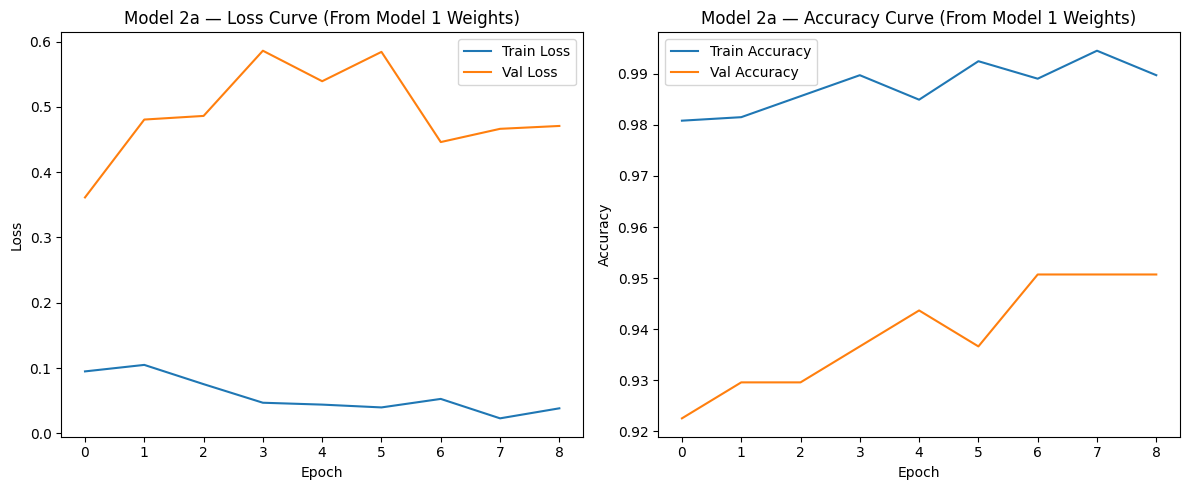

=== Model 2a (Transfer Learning from Model 1) — Test Set Results ===
                         precision    recall  f1-score   support

         adenocarcinoma       0.91      0.88      0.89       120
   large.cell.carcinoma       0.89      1.00      0.94        51
        malignant_cases       0.95      0.86      0.90        80
                 normal       0.91      0.96      0.94       134
squamous.cell.carcinoma       0.91      0.88      0.89        90

               accuracy                           0.91       475
              macro avg       0.91      0.92      0.91       475
           weighted avg       0.91      0.91      0.91       475



In [ ]:
### Model 2a Diagnostics

epochs_range2a = range(len(train_accs))
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range2a, train_losses, label="Train Loss")
plt.plot(epochs_range2a, val_losses,   label="Val Loss")
plt.title("Model 2a — Loss Curve (From Model 1 Weights)")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range2a, train_accs, label="Train Accuracy")
plt.plot(epochs_range2a, val_accs,   label="Val Accuracy")
plt.title("Model 2a — Accuracy Curve (From Model 1 Weights)")
plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.legend()
plt.tight_layout()
plt.show()

model.load_state_dict(torch.load("model2a_best.pth", map_location=device))
model.eval()

m2a_preds, m2a_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        m2a_preds.extend(preds)
        m2a_labels.extend(labels.numpy())

print("=== Model 2a (Transfer Learning from Model 1) — Test Set Results ===")
print(classification_report(m2a_labels, m2a_preds, target_names=test_ds.classes))

In [ ]:
# If model2b_best.pth is missing, re-run the Model 2b training block above
import os
print("model2b_best.pth exists:", os.path.exists("model2b_best.pth"))
print("model2a_best.pth exists:", os.path.exists("model2a_best.pth"))
print("model1_best.pth exists:", os.path.exists("model1_best.pth"))

model2b_best.pth exists: True
model2a_best.pth exists: True
model1_best.pth exists: True


### Model 2b Diagnostics

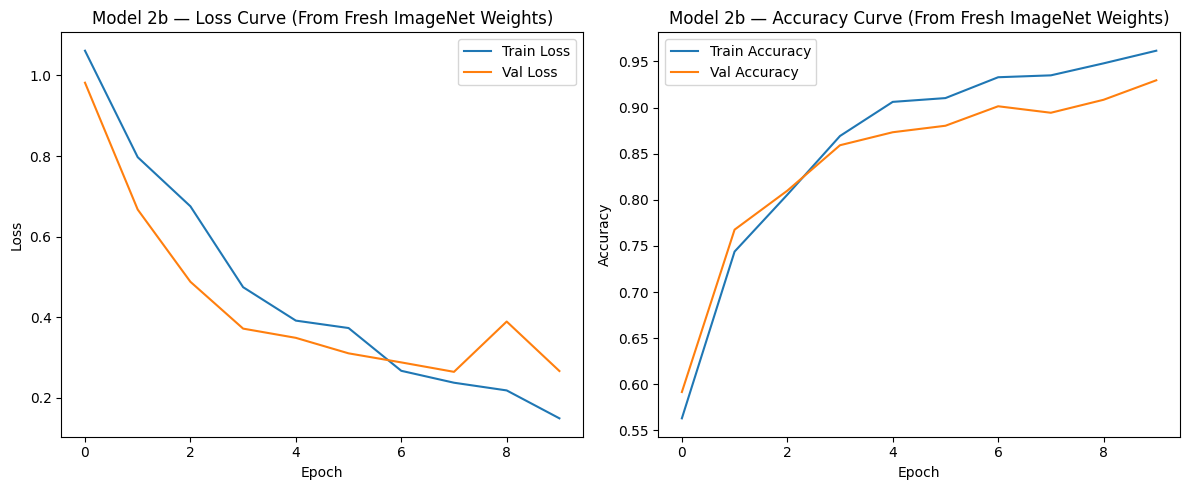

=== Model 2b (Transfer Learning from Fresh Weights) — Test Set Results ===
                         precision    recall  f1-score   support

         adenocarcinoma       0.92      0.78      0.84       120
   large.cell.carcinoma       0.81      0.92      0.86        51
        malignant_cases       0.94      0.82      0.88        80
                 normal       0.90      0.96      0.93       134
squamous.cell.carcinoma       0.79      0.90      0.84        90

               accuracy                           0.88       475
              macro avg       0.87      0.88      0.87       475
           weighted avg       0.88      0.88      0.88       475



In [ ]:
epochs_range2b = range(len(train_losses2))
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range2b, train_losses2, label="Train Loss")
plt.plot(epochs_range2b, val_losses2,   label="Val Loss")
plt.title("Model 2b — Loss Curve (From Fresh ImageNet Weights)")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range2b, train_accs2, label="Train Accuracy")
plt.plot(epochs_range2b, val_accs2,   label="Val Accuracy")
plt.title("Model 2b — Accuracy Curve (From Fresh ImageNet Weights)")
plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.legend()
plt.tight_layout()
plt.show()

model.load_state_dict(torch.load("model2b_best.pth", map_location=device))
model.eval()

m2b_preds, m2b_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        m2b_preds.extend(preds)
        m2b_labels.extend(labels.numpy())

print("=== Model 2b (Transfer Learning from Fresh Weights) — Test Set Results ===")
print(classification_report(m2b_labels, m2b_preds, target_names=test_ds.classes))

Model 2a is essentially equal to Model 1, meaning the transfer learning from an already fine-tuned model didn't meaningfully help or hurt, it just stabilized training faster.
Model 2b is notably worse, which is the interesting finding, starting from fresh ImageNet weights with a frozen backbone severely limits what Phase 1 can learn (30% → 45% in Phase 1), and even after unfreezing in Phase 2 it never fully catches up.
This suggests that for small medical imaging datasets, full fine-tuning from the start beats structured transfer learning from scratch.

## Baseline Model: PCA + Logistic Regression

To contextualize our deep learning results, we establish a classical baseline using **Principal Component Analysis (PCA)** for dimensionality reduction followed by **multinomial Logistic Regression**.

Each 224×224 RGB image is flattened to a 150,528-dimensional vector. PCA reduces this to 100 components (capturing the majority of variance) before classification. This is representative of how lung CT images would have been analyzed before deep learning became dominant.

We apply the same `balanced` class weighting to logistic regression for a fair comparison.

In [ ]:
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

print("Extracting flattened image features...")

def extract_flat_features(dataset):
    features, labels_list = [], []
    for img_tensor, label in dataset:
        features.append(img_tensor.numpy().flatten())
        labels_list.append(label)
    return np.array(features), np.array(labels_list)

X_train, y_train = extract_flat_features(train_ds)
X_val,   y_val   = extract_flat_features(val_ds)
X_test,  y_test  = extract_flat_features(test_ds)
print(f"Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")

# Standardize then PCA
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Fitting PCA (100 components)...")
pca = PCA(n_components=100, random_state=SEED)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca  = pca.transform(X_test_scaled)
print(f"Explained variance: {pca.explained_variance_ratio_.sum():.3f}")

# Logistic Regression
print("Training Logistic Regression...")
lr_model = LogisticRegression(
    max_iter=3000,
    class_weight='balanced',
    solver='saga',
    random_state=SEED
)
lr_model.fit(X_train_pca, y_train)

baseline_preds = lr_model.predict(X_test_pca)
print("\n=== Baseline (PCA + Logistic Regression) — Test Set Results ===")
print(classification_report(y_test, baseline_preds, target_names=test_ds.classes))

Extracting flattened image features...
Train: (1460, 150528) | Val: (142, 150528) | Test: (475, 150528)
Fitting PCA (100 components)...
Explained variance: 0.830
Training Logistic Regression...

=== Baseline (PCA + Logistic Regression) — Test Set Results ===
                         precision    recall  f1-score   support

         adenocarcinoma       0.40      0.16      0.23       120
   large.cell.carcinoma       0.39      0.71      0.50        51
        malignant_cases       0.77      0.59      0.67        80
                 normal       0.76      0.70      0.73       134
squamous.cell.carcinoma       0.38      0.64      0.48        90

               accuracy                           0.53       475
              macro avg       0.54      0.56      0.52       475
           weighted avg       0.56      0.53      0.52       475



## Confusion Matrices

Confusion matrices reveal *where* each model makes mistakes. Key things to look for:
- Are cancer types being confused with each other (type confusion)?
- Are cancerous cases being predicted as normal (false negatives — most dangerous)?
- Are normal cases being predicted as cancerous (false positives — costly but less harmful)?

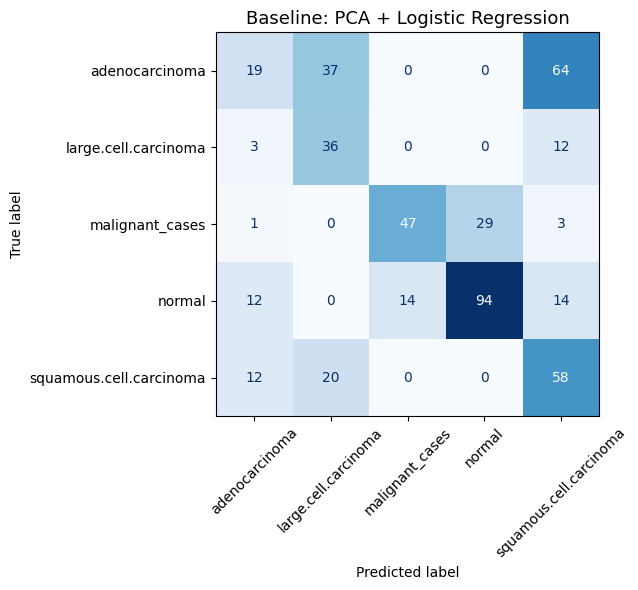

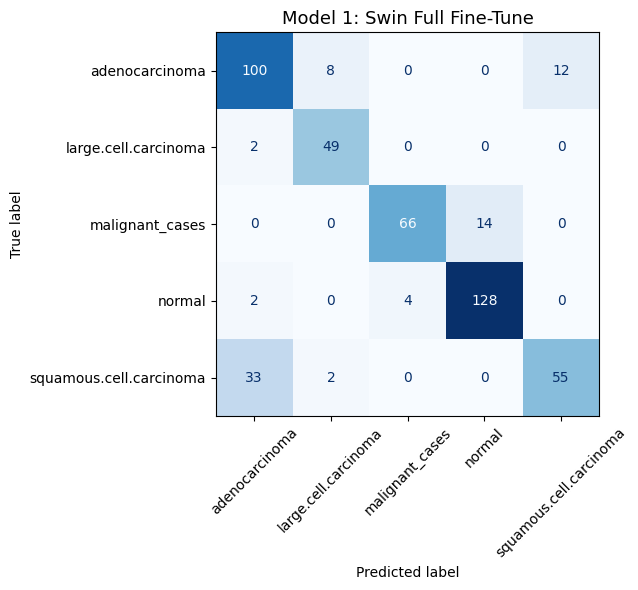

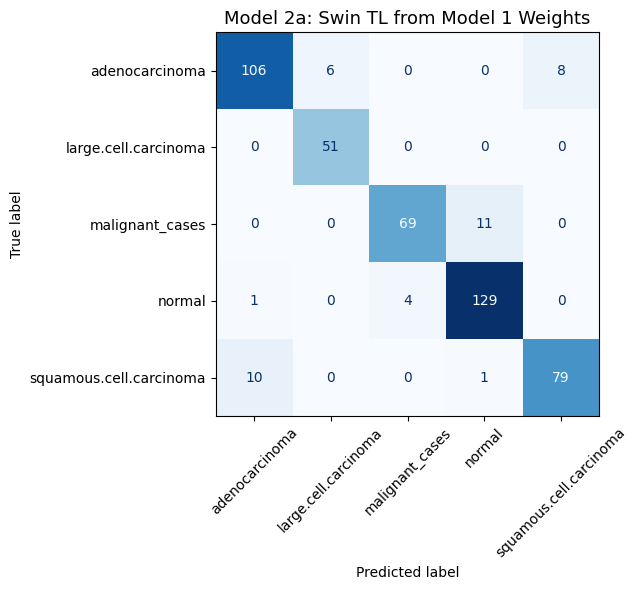

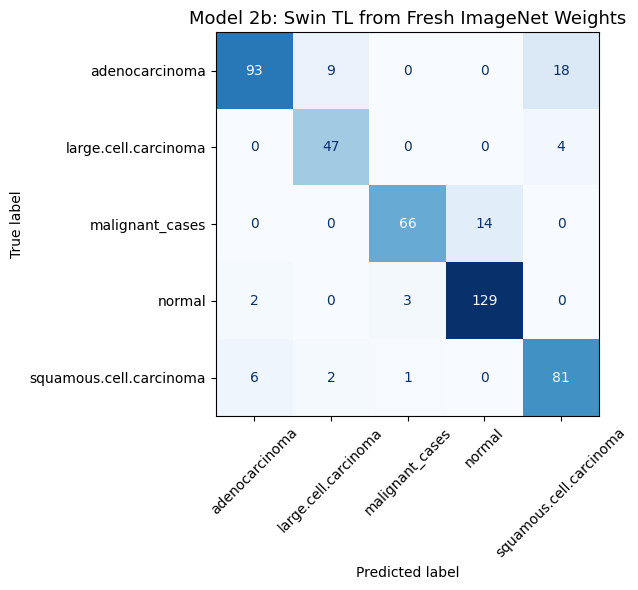

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def plot_confusion_matrix(labels, preds, class_names, title):
    cm = confusion_matrix(labels, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    fig, ax = plt.subplots(figsize=(8, 6))
    disp.plot(ax=ax, colorbar=False, cmap="Blues", xticks_rotation=45)
    ax.set_title(title, fontsize=13)
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(y_test,     baseline_preds, test_ds.classes, "Baseline: PCA + Logistic Regression")
plot_confusion_matrix(all_labels, all_preds,      test_ds.classes, "Model 1: Swin Full Fine-Tune")
plot_confusion_matrix(m2a_labels, m2a_preds,      test_ds.classes, "Model 2a: Swin TL from Model 1 Weights")
plot_confusion_matrix(m2b_labels, m2b_preds,      test_ds.classes, "Model 2b: Swin TL from Fresh ImageNet Weights")

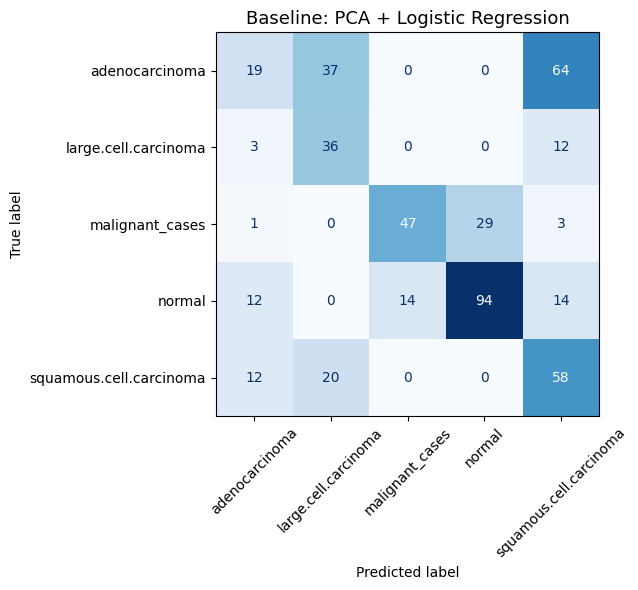

In [ ]:
# Figure 4 — place in Section 3.2
plot_confusion_matrix(y_test, baseline_preds, test_ds.classes, "Baseline: PCA + Logistic Regression")

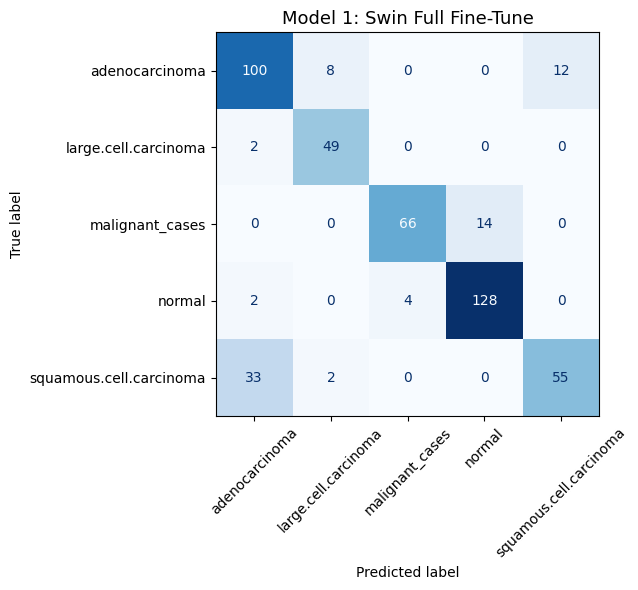

In [ ]:
# Figure 5 — place in Section 3.3
plot_confusion_matrix(all_labels, all_preds, test_ds.classes, "Model 1: Swin Full Fine-Tune")

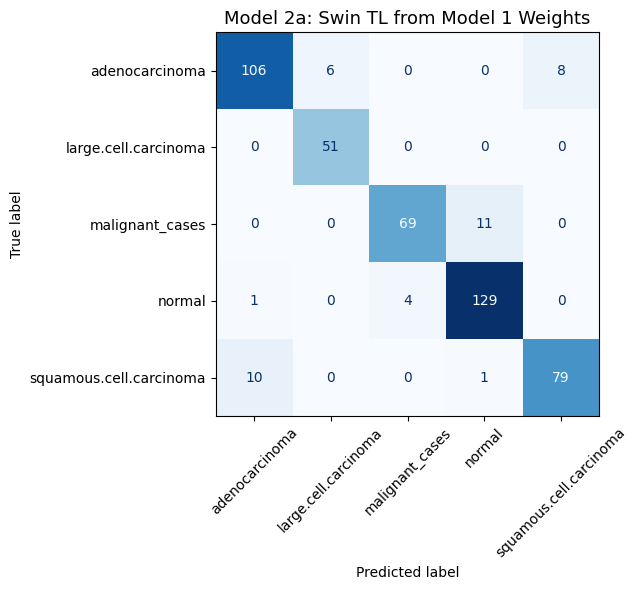

In [ ]:
# Figure 6 — place in Section 3.4
plot_confusion_matrix(m2a_labels, m2a_preds, test_ds.classes, "Model 2a: Swin TL from Model 1 Weights")

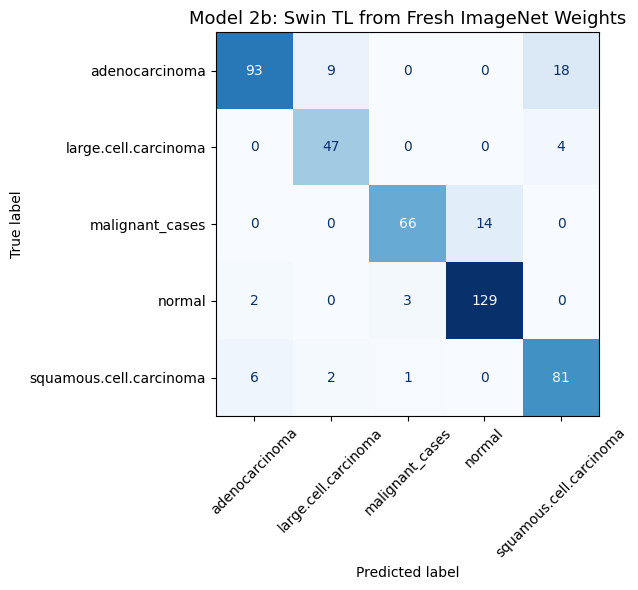

In [ ]:
# Figure 7 — place in Section 3.5
plot_confusion_matrix(m2b_labels, m2b_preds, test_ds.classes, "Model 2b: Swin TL from Fresh ImageNet Weights")

## Model Comparison

We summarize all three models on test accuracy, macro-averaged F1, and macro-averaged recall. Recall is our primary metric of interest since a missed positive (false negative) is more harmful than a false alarm in cancer detection.

In [ ]:
# Reload Model 1 preds if needed
model.load_state_dict(torch.load("model1_best.pth", map_location=device))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())

In [ ]:
from sklearn.metrics import f1_score, recall_score, accuracy_score

# Pull Model 1 preds from the classification report block (all_preds / all_labels)
results = {
    "Model": [
        "Baseline (PCA + LR)",
        "Swin Full Fine-Tune (Model 1)",
        "Swin TL from Model 1 (Model 2a)",
        "Swin TL from Scratch (Model 2b)",
    ],
    "Test Accuracy": [
        accuracy_score(y_test,    baseline_preds),
        accuracy_score(all_labels, all_preds),
        accuracy_score(m2a_labels, m2a_preds),
        accuracy_score(m2b_labels, m2b_preds),
    ],
    "Macro F1": [
        f1_score(y_test,    baseline_preds, average='macro'),
        f1_score(all_labels, all_preds,     average='macro'),
        f1_score(m2a_labels, m2a_preds,     average='macro'),
        f1_score(m2b_labels, m2b_preds,     average='macro'),
    ],
    "Macro Recall": [
        recall_score(y_test,    baseline_preds, average='macro'),
        recall_score(all_labels, all_preds,     average='macro'),
        recall_score(m2a_labels, m2a_preds,     average='macro'),
        recall_score(m2b_labels, m2b_preds,     average='macro'),
    ],
}

comparison_df = pd.DataFrame(results)
comparison_df[["Test Accuracy", "Macro F1", "Macro Recall"]] = \
    comparison_df[["Test Accuracy", "Macro F1", "Macro Recall"]].map(lambda x: f"{x:.4f}")

print(comparison_df.to_string(index=False))

from google.colab import files
files.download("model2a_best.pth")

                          Model Test Accuracy Macro F1 Macro Recall
            Baseline (PCA + LR)        0.5347   0.5214       0.5595
  Swin Full Fine-Tune (Model 1)        0.8379   0.8355       0.8371
Swin TL from Model 1 (Model 2a)        0.9137   0.9144       0.9173
Swin TL from Scratch (Model 2b)        0.8758   0.8710       0.8769


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>